# Telco Customer Churn — Complete EDA & Data Cleaning
**Course:** STT 811 | **Semester:** Spring 2026

---

## STEP 1 — Install / Import Libraries

In [1]:
# Run this cell once if any library is missing
# !pip install pandas numpy matplotlib seaborn scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

print('All libraries imported successfully!')

All libraries imported successfully!


---
## STEP 2 — Load Data

In [3]:
df_raw = pd.read_excel("data/Telco_customer_churn.xlsx")
df     = df_raw.copy()   # working copy — df_raw stays untouched

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 7,043 rows × 33 columns


---
## STEP 3 — First Look at the Data

In [4]:
# First 5 rows
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.96,-118.27,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.06,-118.31,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.05,-118.29,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.06,-118.32,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.04,-118.27,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [5]:
# Last 5 rows
df.tail()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.34,-116.54,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.67,-117.54,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.56,-115.64,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.17,-116.86,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.42,-117.18,Male,No,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No,0,38,5097,NaN


In [6]:
# Column names, dtypes, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [7]:
# Descriptive statistics — numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Zip Code,7043.00,93521.96,1865.79,90001.00,92102.00,93552.00,95351.00,96161.00
Latitude,7043.00,36.28,2.46,32.56,34.03,36.39,38.22,41.96
Longitude,7043.00,-119.80,2.16,-124.30,-121.82,-119.73,-118.04,-114.19
Tenure Months,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
Monthly Charges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75
Churn Value,7043.00,0.27,0.44,0.00,0.00,0.00,1.00,1.00
Churn Score,7043.00,58.70,21.53,5.00,40.00,61.00,75.00,100.00
CLTV,7043.00,4400.30,1183.06,2003.00,3469.00,4527.00,5380.50,6500.00


In [8]:
# Descriptive statistics — categorical columns
df.describe(include='object').T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"33.964131, -118.272783",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [9]:
# Unique values per column
unique_vals = pd.DataFrame({
    'dtype'       : df.dtypes,
    'unique_count': df.nunique(),
    'sample_values': [df[c].dropna().unique()[:4].tolist() for c in df.columns]
})
unique_vals

,dtype,unique_count,sample_values
CustomerID,object,7043,"[3668-QPYBK, 9237-HQITU, 9305-CDSKC, 7892-POOKP]"
Count,int64,1,[1]
Country,object,1,[United States]
State,object,1,[California]
City,object,1129,"[Los Angeles, Beverly Hills, Huntington Park, ..."
Zip Code,int64,1652,"[90003, 90005, 90006, 90010]"
Lat Long,object,1652,"[33.964131, -118.272783, 34.059281, -118.30742..."
Latitude,float64,1652,"[33.964131, 34.059281, 34.048013, 34.062125]"
Longitude,float64,1651,"[-118.272783, -118.30742, -118.293953, -118.31..."
Gender,object,2,"[Male, Female]"


---
## STEP 4 — Missing Values

In [10]:
# ── Raw missing counts ──────────────────────────────────────────────────────
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %'    : missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print('=== Columns with Missing Values ===')
if missing_df.empty:
    print('  → No missing values detected in raw data.')
else:
    print(missing_df)

=== Columns with Missing Values ===
              Missing Count  Missing %
Churn Reason           5174      73.46


In [11]:
# ── Total Charges is stored as string — has blank spaces where tenure = 0 ──
print('Total Charges dtype (before fix):', df['Total Charges'].dtype)
print('\nSample blank/space values:')
print(df[df['Total Charges'].astype(str).str.strip() == ''][['CustomerID','Tenure Months','Monthly Charges','Total Charges']].head())

# Convert to float
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print(f'\nNaN in Total Charges after conversion: {df["Total Charges"].isnull().sum()}')

Total Charges dtype (before fix): object

Sample blank/space values:
      CustomerID  Tenure Months  Monthly Charges Total Charges
2234  4472-LVYGI              0            52.55              
2438  3115-CZMZD              0            20.25              
2568  5709-LVOEQ              0            80.85              
2667  4367-NUYAO              0            25.75              
2856  1371-DWPAZ              0            56.05              

NaN in Total Charges after conversion: 11


In [12]:
# Inspect those rows
df[df['Total Charges'].isnull()][
    ['CustomerID','Tenure Months','Monthly Charges','Total Charges','Churn Label']
]

,CustomerID,Tenure Months,Monthly Charges,Total Charges,Churn Label
2234,4472-LVYGI,0,52.55,NaN,No
2438,3115-CZMZD,0,20.25,NaN,No
2568,5709-LVOEQ,0,80.85,NaN,No
2667,4367-NUYAO,0,25.75,NaN,No
2856,1371-DWPAZ,0,56.05,NaN,No
4331,7644-OMVMY,0,19.85,NaN,No
4687,3213-VVOLG,0,25.35,NaN,No
5104,2520-SGTTA,0,20.00,NaN,No
5719,2923-ARZLG,0,19.70,NaN,No
6772,4075-WKNIU,0,73.35,NaN,No


In [13]:
# These are brand-new customers (tenure ~ 0) → fill with Monthly Charges
mask = df['Total Charges'].isnull()
df.loc[mask, 'Total Charges'] = df.loc[mask, 'Monthly Charges']
print(f'Remaining NaN in Total Charges: {df["Total Charges"].isnull().sum()}')

Remaining NaN in Total Charges: 0


---
## STEP 5 — Target Variable: Churn

In [14]:
churn_counts = df['Churn Label'].value_counts()
churn_pct    = df['Churn Label'].value_counts(normalize=True) * 100

print('=== Churn Distribution ===')
print(pd.DataFrame({'Count': churn_counts, 'Percent %': churn_pct.round(2)}))

=== Churn Distribution ===
             Count  Percent %
Churn Label                  
No            5174      73.46
Yes           1869      26.54


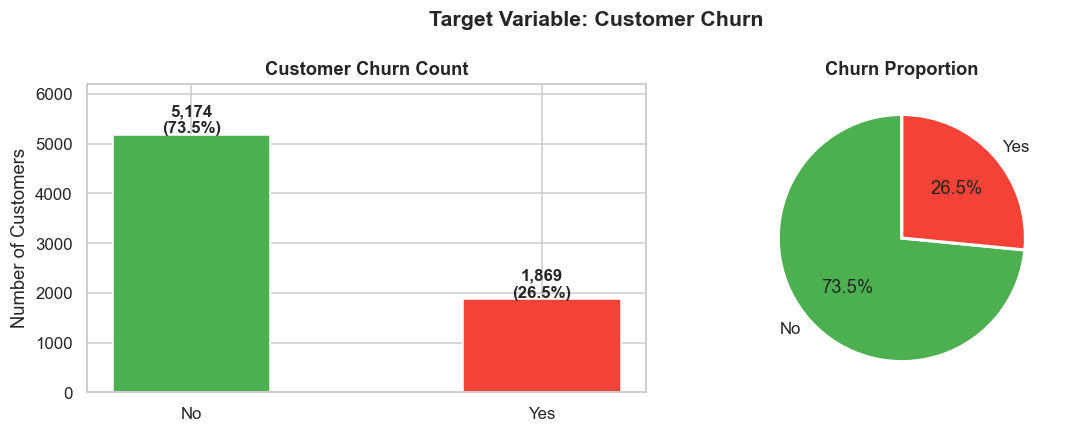

In [15]:
colors = ['#4CAF50', '#F44336']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=colors, edgecolor='white', width=0.45)
for bar, val, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 40,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Customer Churn Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, max(churn_counts.values) * 1.2)

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Proportion', fontsize=12, fontweight='bold')

plt.suptitle('Target Variable: Customer Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

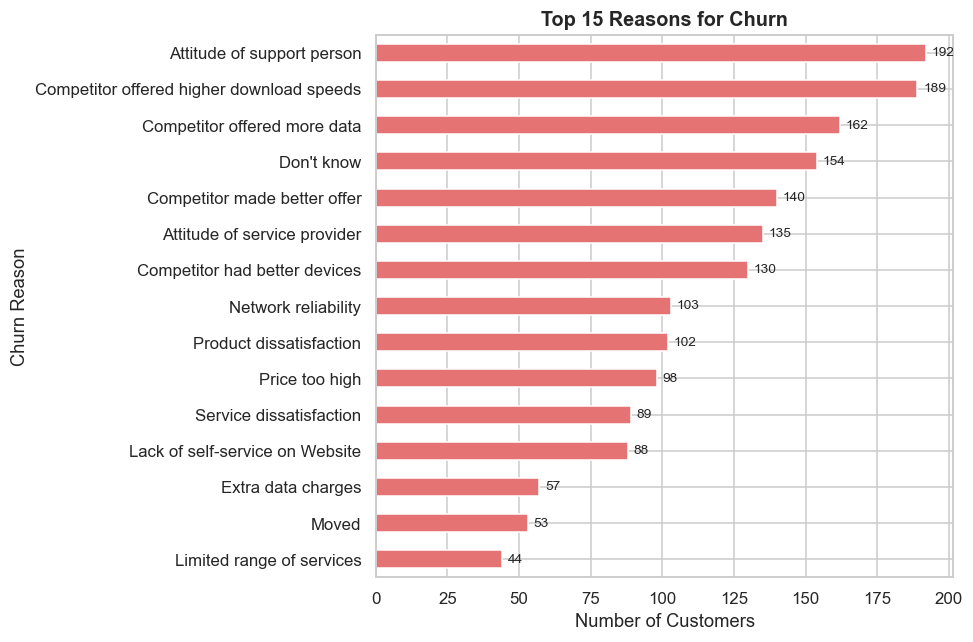

In [16]:
# Top churn reasons (churned customers only)
churn_reasons = (
    df[df['Churn Label'] == 'Yes']['Churn Reason']
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
churn_reasons.sort_values().plot(kind='barh', ax=ax,
                                  color='#E57373', edgecolor='white')
for i, val in enumerate(churn_reasons.sort_values().values):
    ax.text(val + 2, i, str(val), va='center', fontsize=9)
ax.set_title('Top 15 Reasons for Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Customers')
plt.tight_layout()
plt.show()

---
## STEP 6 — Univariate Analysis: Numeric Features

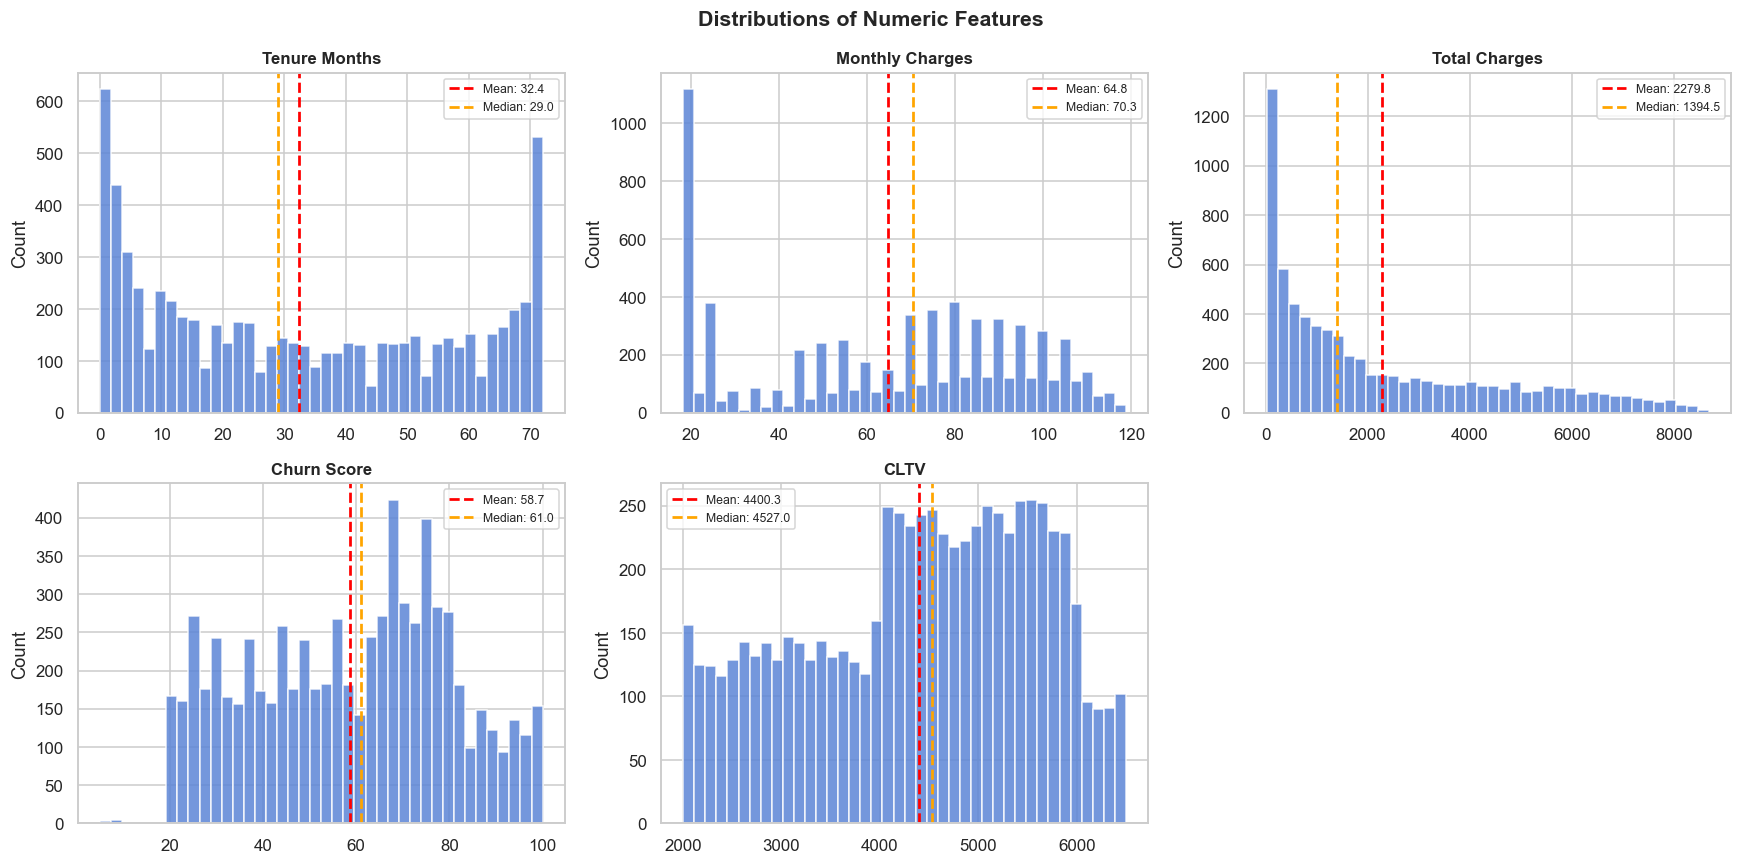

In [17]:
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='#5C85D6', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(),   color='red',    linestyle='--', lw=1.8,
                    label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', lw=1.8,
                    label=f'Median: {data.median():.1f}')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distributions of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

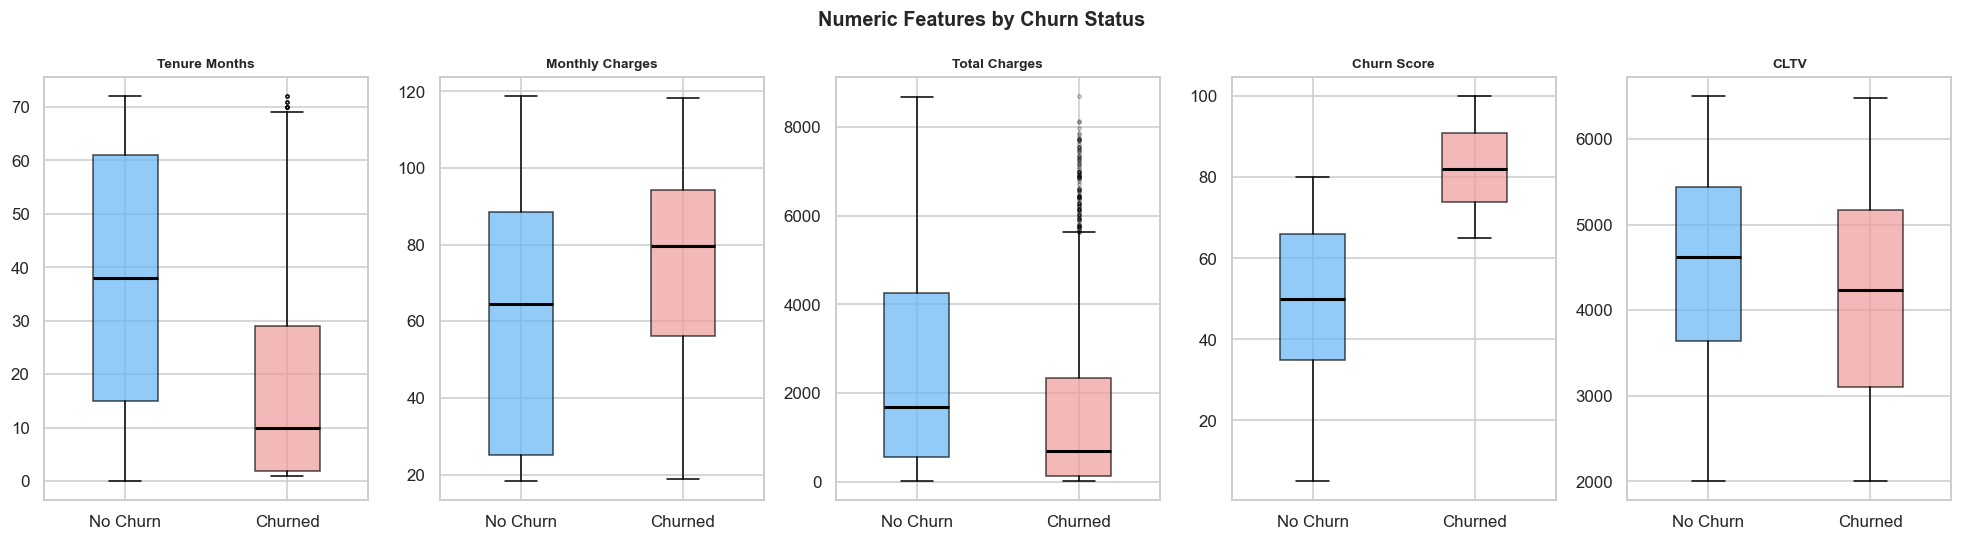

In [18]:
# Box plots — numeric features split by Churn
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    for label, color in zip(['No', 'Yes'], ['#64B5F6', '#EF9A9A']):
        subset = df[df['Churn Label'] == label][col].dropna()
        ax.boxplot(
            subset, positions=[0 if label == 'No' else 1],
            widths=0.4, patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.7),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray')
        )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Churn', 'Churned'])
    ax.set_title(col, fontsize=9, fontweight='bold')

plt.suptitle('Numeric Features by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Skewness & Kurtosis summary
skew_kurt = pd.DataFrame({
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurt()
}).round(3)
print('=== Skewness & Kurtosis ===')
print(skew_kurt)

=== Skewness & Kurtosis ===
                 Skewness  Kurtosis
Tenure Months        0.24     -1.39
Monthly Charges     -0.22     -1.26
Total Charges        0.96     -0.23
Churn Score         -0.09     -1.01
CLTV                -0.31     -0.93


---
## STEP 7 — Univariate Analysis: Categorical Features

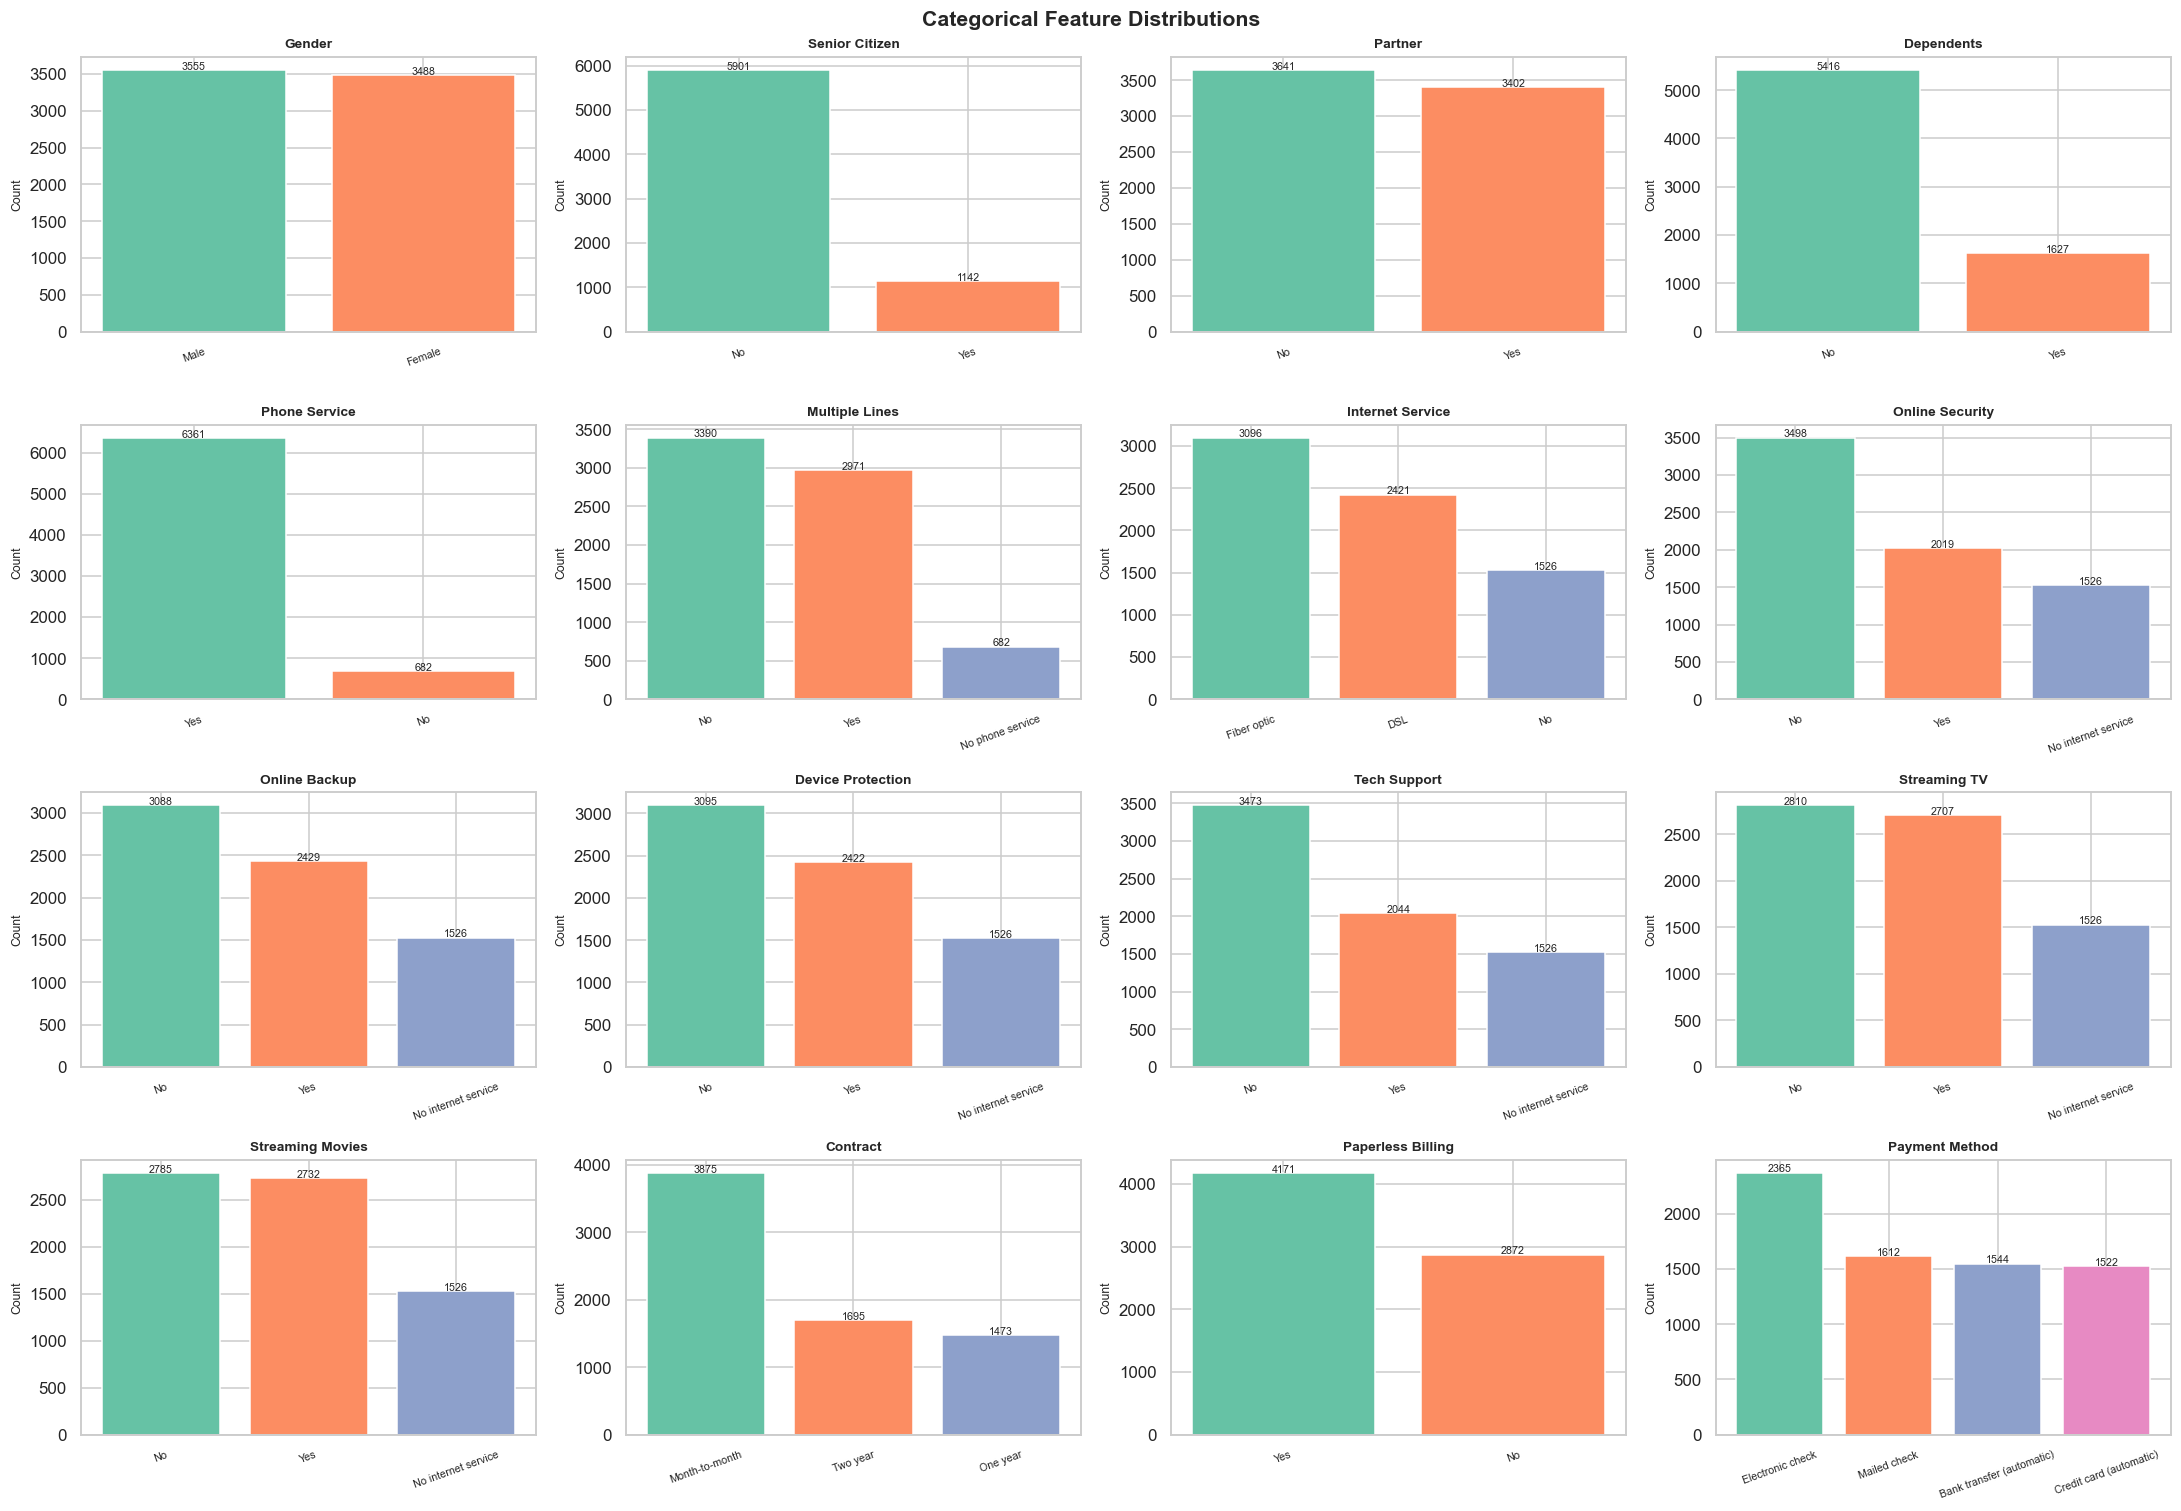

In [20]:
cat_cols = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents',
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Paperless Billing', 'Payment Method'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc     = df[col].value_counts()
    colors = sns.color_palette('Set2', len(vc))
    bars   = axes[i].bar(vc.index, vc.values, color=colors, edgecolor='white')
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20, labelsize=7)
    axes[i].set_ylabel('Count', fontsize=8)
    for bar, v in zip(bars, vc.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, v + 10,
                     str(v), ha='center', fontsize=7)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## STEP 8 — Bivariate Analysis: Features vs Churn

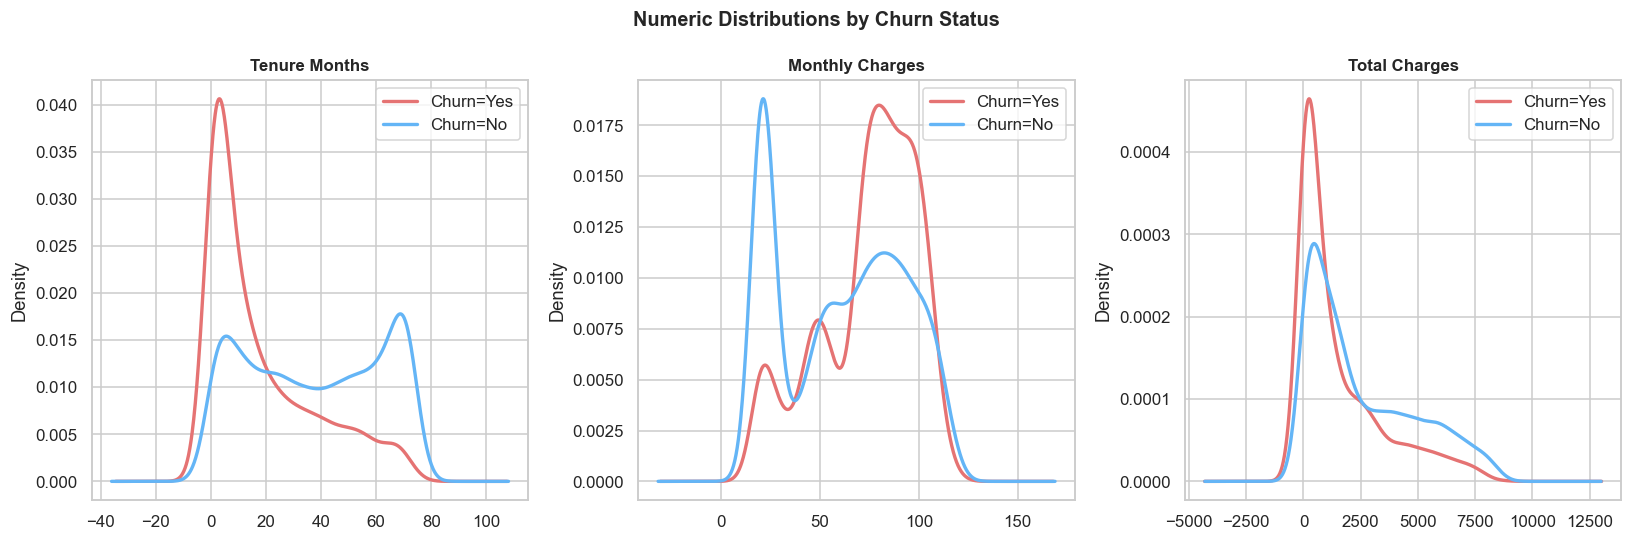

In [21]:
# KDE: numeric features split by Churn
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Tenure Months', 'Monthly Charges', 'Total Charges']):
    for label, color in zip(['Yes', 'No'], ['#E57373', '#64B5F6']):
        df[df['Churn Label'] == label][col].dropna().plot.kde(
            ax=ax, label=f'Churn={label}', color=color, linewidth=2.2
        )
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Numeric Distributions by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

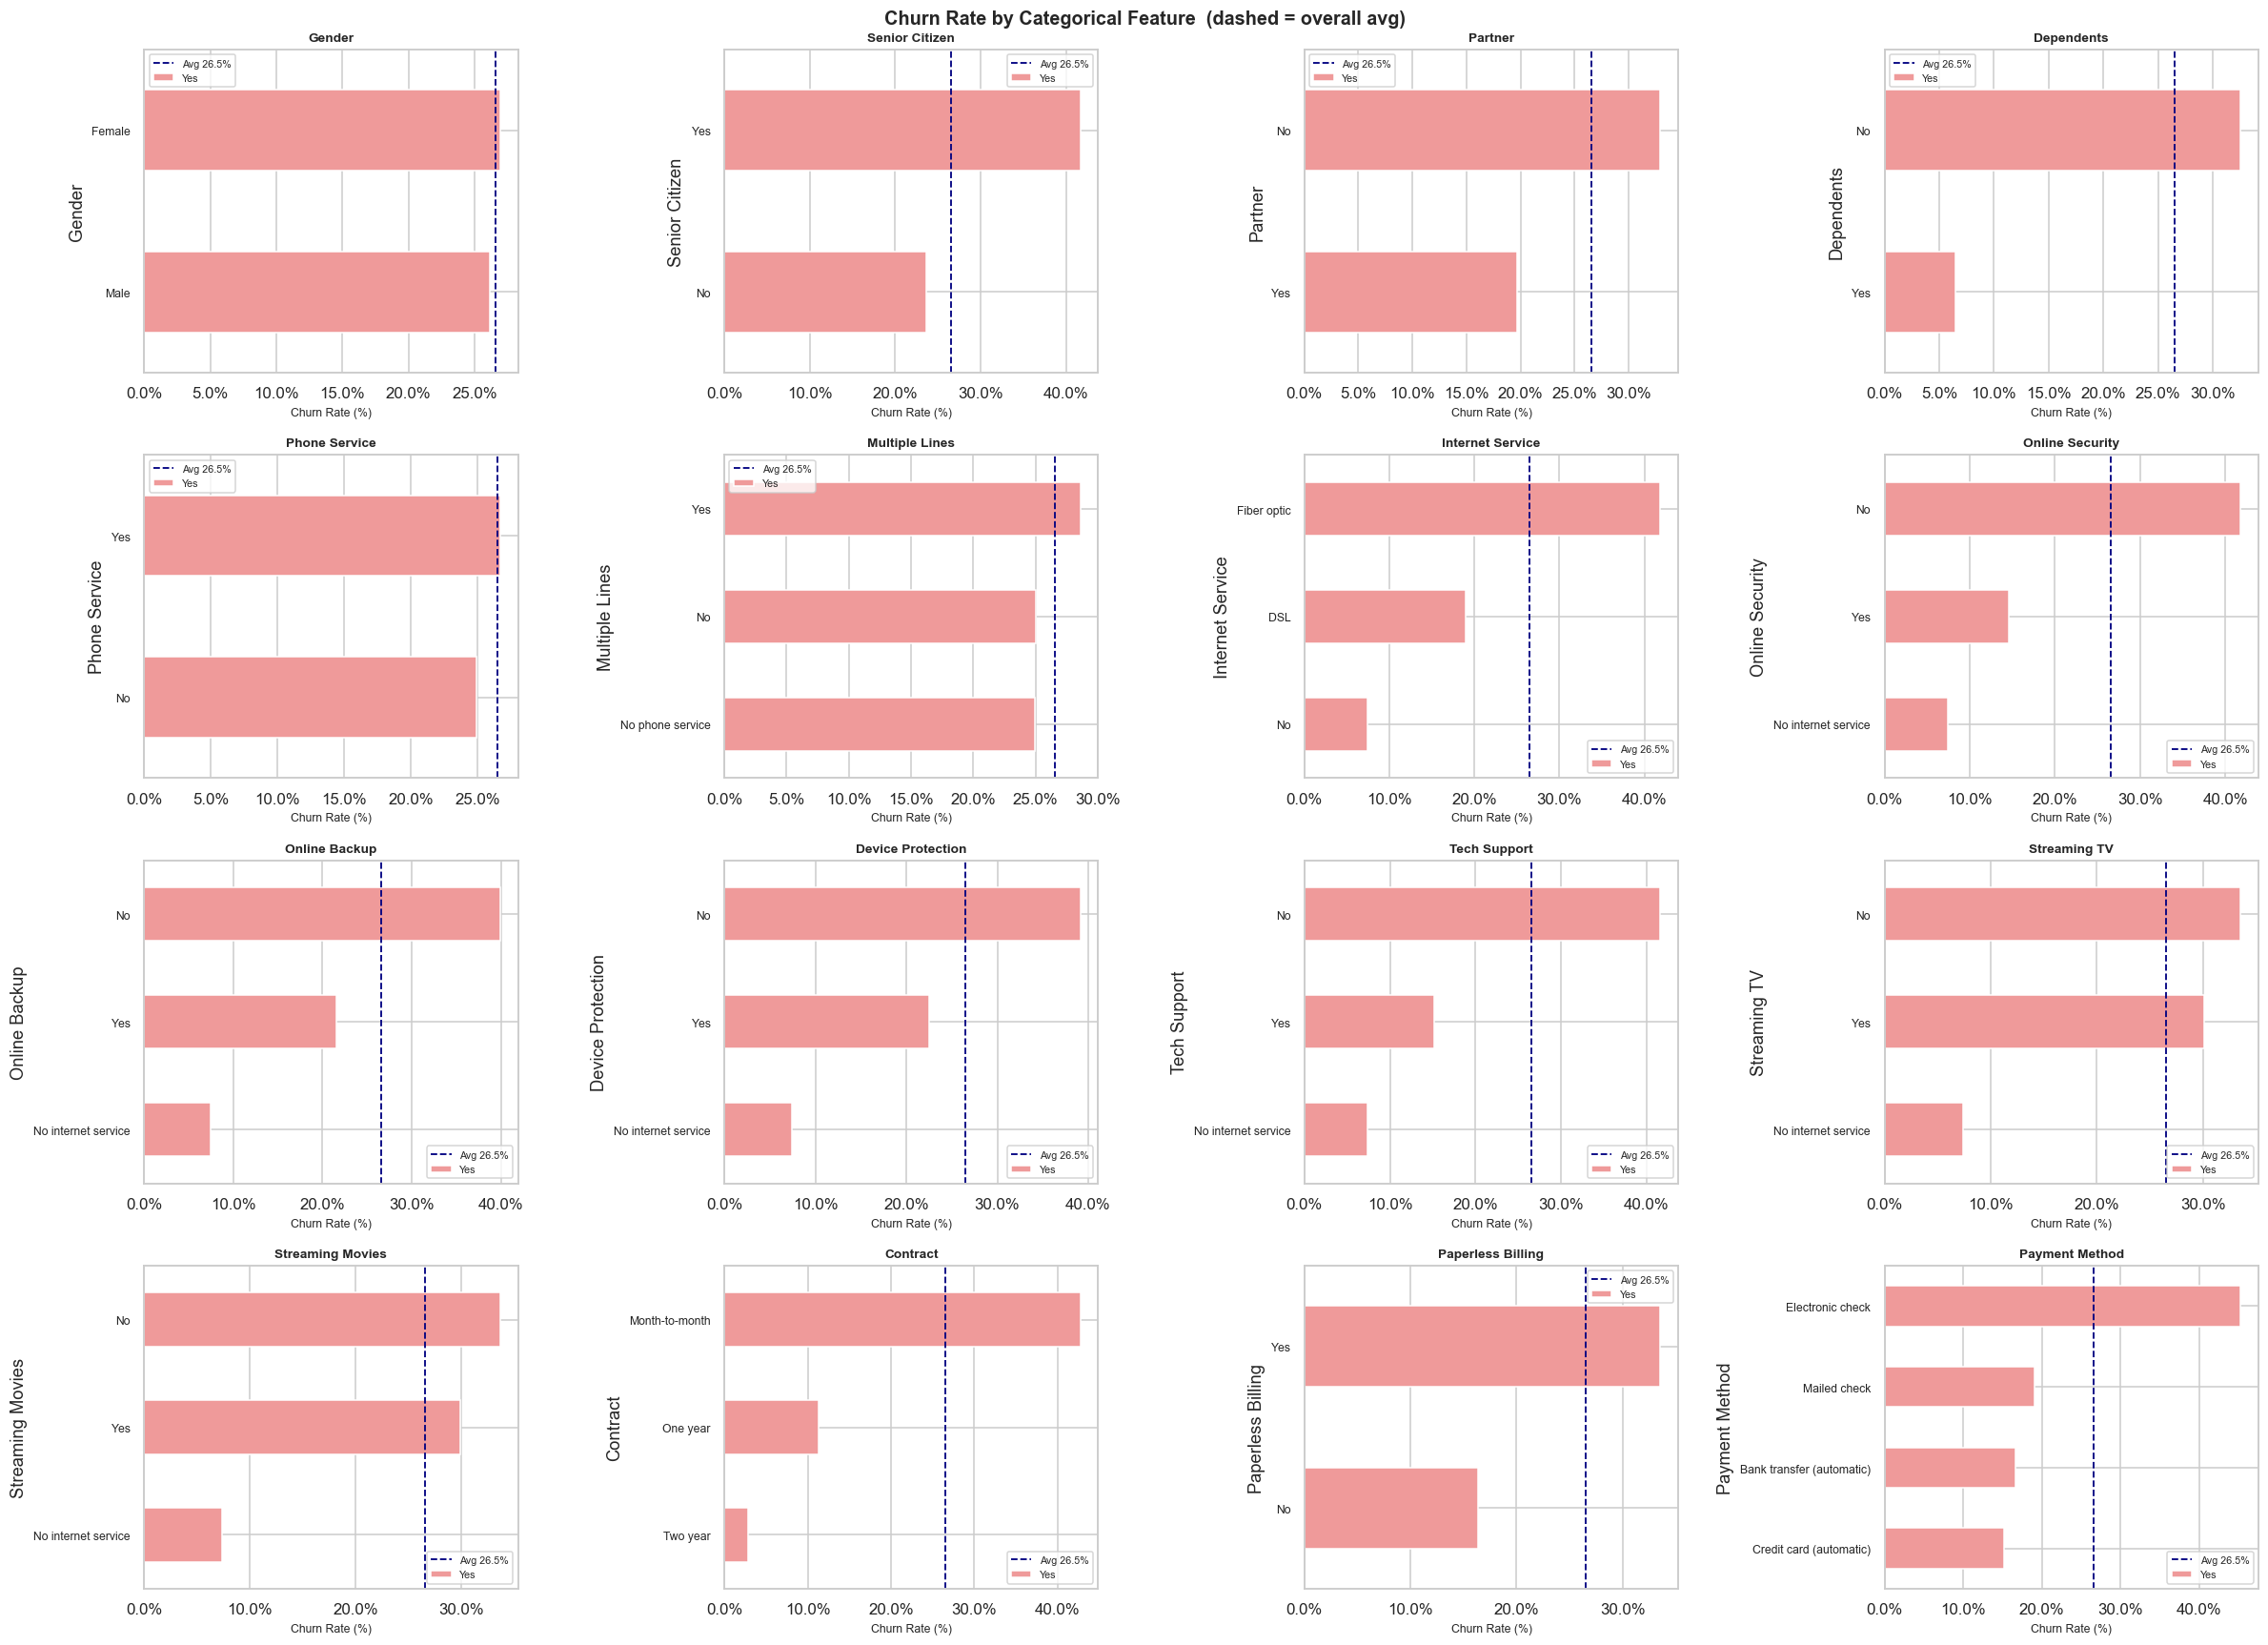

In [22]:
# Churn rate (%) for every categorical feature
overall_churn_rate = df['Churn Value'].mean() * 100

fig, axes = plt.subplots(4, 4, figsize=(22, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn Label'], normalize='index') * 100
    if 'Yes' in ct.columns:
        ct['Yes'].sort_values().plot(
            kind='barh', ax=axes[i], color='#EF9A9A', edgecolor='white'
        )
        axes[i].axvline(overall_churn_rate, color='navy',
                        linestyle='--', linewidth=1.2, label=f'Avg {overall_churn_rate:.1f}%')
        axes[i].set_title(f'{col}', fontsize=9, fontweight='bold')
        axes[i].set_xlabel('Churn Rate (%)', fontsize=8)
        axes[i].tick_params(axis='y', labelsize=8)
        axes[i].xaxis.set_major_formatter(mtick.PercentFormatter())
        axes[i].legend(fontsize=7)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature  (dashed = overall avg)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

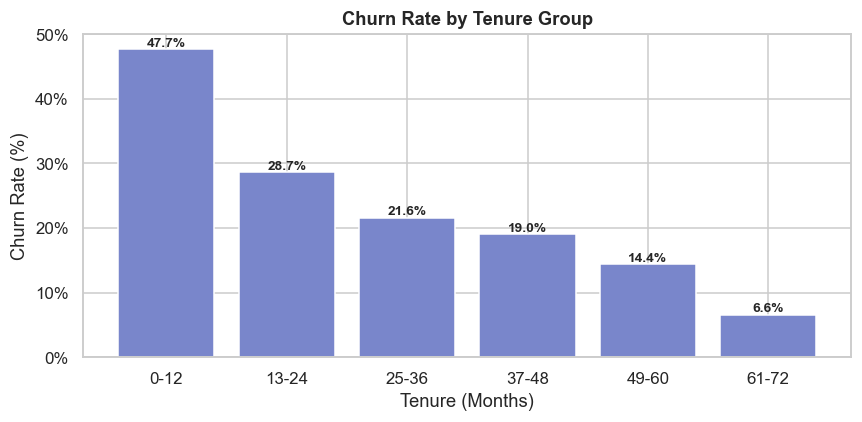

In [23]:
# Tenure groups vs Churn rate
df['Tenure Group'] = pd.cut(
    df['Tenure Months'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
)
tenure_churn = df.groupby('Tenure Group')['Churn Value'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(tenure_churn.index, tenure_churn.values,
              color='#7986CB', edgecolor='white')
for bar, val in zip(bars, tenure_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.4,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Churn Rate by Tenure Group', fontsize=12, fontweight='bold')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Churn Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

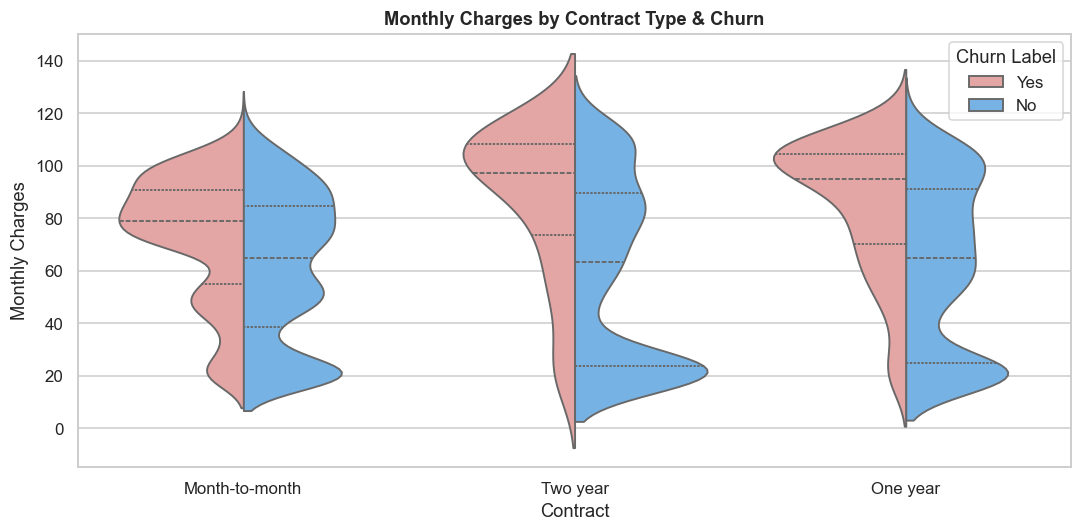

In [24]:
# Monthly charges vs Contract type (violin)
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df, x='Contract', y='Monthly Charges',
    hue='Churn Label', split=True, inner='quart',
    palette={'No': '#64B5F6', 'Yes': '#EF9A9A'}, ax=ax
)
ax.set_title('Monthly Charges by Contract Type & Churn', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## STEP 9 — Correlation Analysis

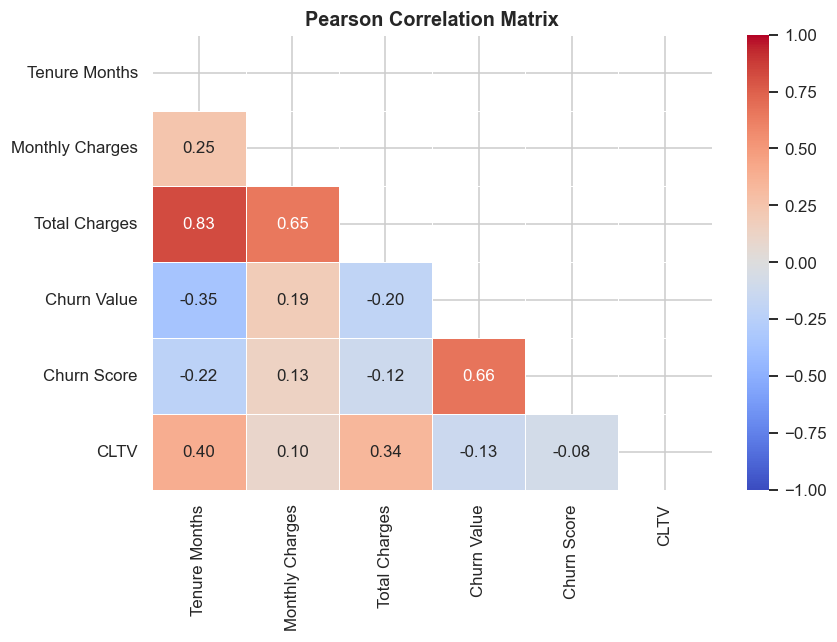

In [25]:
# Pearson correlation heatmap
corr_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges',
             'Churn Value', 'Churn Score', 'CLTV']
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 11}, ax=ax)
ax.set_title('Pearson Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Point-biserial correlation with Churn Value
pb_results = {}
for col in ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']:
    clean = df[[col, 'Churn Value']].dropna()
    r, p  = pointbiserialr(clean['Churn Value'], clean[col])
    pb_results[col] = {'r': round(r, 4), 'p-value': round(p, 6),
                       'Significant': 'Yes' if p < 0.05 else 'No'}

pb_df = pd.DataFrame(pb_results).T.sort_values('r', key=abs, ascending=False)
print('=== Point-Biserial Correlation with Churn ===')
print(pb_df)

=== Point-Biserial Correlation with Churn ===
                    r p-value Significant
Churn Score      0.66    0.00         Yes
Tenure Months   -0.35    0.00         Yes
Total Charges   -0.20    0.00         Yes
Monthly Charges  0.19    0.00         Yes
CLTV            -0.13    0.00         Yes


In [27]:
# Chi-square test: categorical features vs Churn
from scipy.stats import chi2_contingency

chi2_results = {}
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Churn Label'])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi2_results[col] = {
        'chi2'       : round(chi2, 2),
        'p-value'    : round(p, 6),
        'Significant': 'Yes ✓' if p < 0.05 else 'No'
    }

chi2_df = pd.DataFrame(chi2_results).T.sort_values('chi2', ascending=False)
print('=== Chi-Square Test: Categorical Features vs Churn ===')
print(chi2_df)

=== Chi-Square Test: Categorical Features vs Churn ===
                     chi2 p-value Significant
Contract          1184.60    0.00       Yes ✓
Online Security    850.00    0.00       Yes ✓
Tech Support       828.20    0.00       Yes ✓
Internet Service   732.31    0.00       Yes ✓
Payment Method     648.14    0.00       Yes ✓
Online Backup      601.81    0.00       Yes ✓
Device Protection  558.42    0.00       Yes ✓
Dependents         433.73    0.00       Yes ✓
Streaming Movies   375.66    0.00       Yes ✓
Streaming TV       374.20    0.00       Yes ✓
Paperless Billing  258.28    0.00       Yes ✓
Senior Citizen     159.43    0.00       Yes ✓
Partner            158.73    0.00       Yes ✓
Multiple Lines      11.33    0.00       Yes ✓
Phone Service        0.92    0.34          No
Gender               0.48    0.49          No


### EDA Summary

| # | Finding | Detail |
|---|---|---|
| 1 | **Overall churn rate** | ~26.5% of customers churned |
| 2 | **Contract type** | Month-to-month churn ~43%; 2-year churn ~3% |
| 3 | **Internet service** | Fiber optic churn ~42% vs DSL ~19% |
| 4 | **Tenure** | New customers (0–12 mo) churn ~50%; drops sharply with age |
| 5 | **Monthly charges** | Churned customers pay ~\$20/mo more on average |
| 6 | **Add-on services** | No Online Security / Tech Support → much higher churn |
| 7 | **Payment method** | Electronic check users churn most (~45%) |
| 8 | **Top churn reasons** | Competitor offers (better devices, price, speed) |

---
## STEP 10 — Data Cleaning

In [28]:
# Start fresh from raw
df_clean = df_raw.copy()

# ── 10a. Fix Total Charges ──────────────────────────────────────────────────
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce')
mask_tc = df_clean['Total Charges'].isnull()
df_clean.loc[mask_tc, 'Total Charges'] = df_clean.loc[mask_tc, 'Monthly Charges']
print(f'Total Charges NaN remaining: {df_clean["Total Charges"].isnull().sum()}')

Total Charges NaN remaining: 0


In [29]:
# ── 10c. Rename target column ───────────────────────────────────────────────
df_clean.rename(columns={'Churn Value': 'Churn'}, inplace=True)
print('Target column renamed to: Churn')

Target column renamed to: Churn


### Cleaning Steps Applied
| Step | Action |
|---|---|
| Fix dtype | `Total Charges` string → float; 11 NaN filled with `Monthly Charges` |
| Renamed Target | changed target name from `Churn Value` to `Churn` |

---
## STEP 11 — Feature Engineering

In [30]:
# Average monthly spend (Total Charges / Tenure)
df_clean['Avg Monthly Spend'] = (
    df_clean['Total Charges'] / df_clean['Tenure Months'].replace(0, 1)
).round(2)

In [31]:
# Tenure Group
df_clean['Tenure Group'] = pd.cut(
    df_clean['Tenure Months'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=[1, 2, 3, 4, 5, 6],
    include_lowest=True
).astype(int)

In [32]:
# Bill Shock Ratio
# Ratio of current monthly charge to their historical average
# > 1 means their bill has gone up; < 1 means it has gone down
df_clean['Bill_Shock_Ratio'] = (
    df_clean['Monthly Charges'] / df_clean['Avg Monthly Spend']
).round(3)

In [33]:
# Service Complexity / "Stickiness" Score
# Count of total internet-based add-on services (count how many columns equal 'Yes')
services = ['Online Security', 'Online Backup', 'Device Protection', 
            'Tech Support', 'Streaming TV', 'Streaming Movies']
df_clean['Total_Addon_Services'] = (df_clean[services] == 'Yes').sum(axis=1)

In [34]:
# Vulnerability Flag (1 if both Security and Support are exactly 'No')
df_clean['High_Risk_Security_Profile'] = (
    (df_clean['Online Security'] == 'No') & 
    (df_clean['Tech Support'] == 'No')
).astype(int)

In [35]:
# Automated Payment Flag
# Create a binary feature: 1 for Auto-pay, 0 for Manual pay
auto_pay_methods = ['Bank transfer (automatic)', 'Credit card (automatic)']
df_clean['Is_Auto_Pay'] = df_clean['Payment Method'].isin(auto_pay_methods).astype(int)

In [36]:
# Cost Per Service
# Monthly charge divided by the number of add-on services (+1 for the base internet connection)
df_clean['Cost_Per_Service'] = (
    df_clean['Monthly Charges'] / (df_clean['Total_Addon_Services'] + 1)
).round(2)

In [37]:
# ── Drop columns not useful for modeling ───────────────────────────────
cols_to_drop = [
    'CustomerID',   # unique identifier — no predictive value
    'Count',        # constant = 1 for every row
    'Country',      # constant = United States
    'State',        # constant = California
    'City',         # too granular; use Zip Code or lat/lon instead if needed
    'Zip Code',     # high cardinality identifier
    'Lat Long',     # duplicate of Latitude + Longitude
    'Latitude',     # geographic — not used in this model
    'Longitude',    # geographic — not used in this model
    'Churn Label',  # string version of target (Churn Value)
    'Churn Score',  # post-hoc derived score → data leakage
    'CLTV',         # post-hoc derived score → data leakage
    'Churn Reason'  # only available after churn happens → data leakage
]

df_clean.drop(columns=cols_to_drop, inplace=True)
print(f'Shape after dropping: {df_clean.shape}')

Shape after dropping: (7043, 27)


In [38]:
# ── Binary encode Yes/No columns ──────────────────────────────────────
binary_yes_no = [
    'Partner', 'Dependents', 'Phone Service', 'Paperless Billing'
]
for col in binary_yes_no:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# Senior Citizen: already 'Yes'/'No' text in this version
df_clean['Senior Citizen'] = df_clean['Senior Citizen'].map({'Yes': 1, 'No': 0})

# Gender
df_clean['Gender'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})

print('Binary encoding complete.')
df_clean[binary_yes_no + ['Senior Citizen', 'Gender']].value_counts().head()

Binary encoding complete.


Partner  Dependents  Phone Service  Paperless Billing  Senior Citizen  Gender
0        0           1              1                  0               1         722
                                                                       0         718
                                    0                  0               1         554
                                                                       0         505
1        0           1              1                  0               0         456
Name: count, dtype: int64

In [39]:
# ── One-hot encode multi-category columns ──────────────────────────────
ohe_cols = [
    'Multiple Lines',    # No / Yes / No phone service
    'Internet Service',  # DSL / Fiber optic / No
    'Online Security',   # No / Yes / No internet service
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Contract',          # Month-to-month / One year / Two year
    'Payment Method'     # 4 categories
]

df_clean = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=False)

# Convert boolean columns created by get_dummies to int (0/1)
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print(f'Shape after one-hot encoding: {df_clean.shape}')

Shape after one-hot encoding: (7043, 48)


### Preprocessing & Feature Engineering Summary

| Step | Action |
|---|---|
| **1. Feature Engineering** | 8 new behavioral and financial features created to capture churn risk (details below) |
| **2. Drop Columns** | 13 leakage / constant / identifier columns removed to prevent overfitting and data leakage |
| **3. Binary Encode** | 6 Yes/No columns + Gender mapped to 0/1 |
| **4. One-Hot Encode** | 10 multi-category columns → dummy variables (applied last to preserve feature engineering logic) |

<br>

#### Engineered Features Detail & Rationale

* **`Avg Monthly Spend`** The historical average spend per month (`Total Charges` / `Tenure Months`). 
  * **Reason:** Provides a baseline of what the customer is used to paying over their lifetime, smoothing out promotional periods.
* **`Tenure Group`** Groups continuous tenure months into 6 ordinal bins (yearly increments).
  * **Reason:** Churn risk often drops non-linearly over time (e.g., a huge drop after year 1). Bins help models capture these specific lifecycle milestones better than raw continuous numbers.
* **`Bill_Shock_Ratio`** The ratio of the current `Monthly Charges` to the `Avg Monthly Spend`.
  * **Reason:** A ratio > 1 indicates the customer's bill has gone up compared to their historical average. Sudden price hikes ("bill shock") are primary triggers for cancellation.
* **`Total_Addon_Services`** A sum of all active internet-based add-on services.
  * **Reason:** Measures "stickiness." Customers with multiple services (security, streaming, backup) are deeply integrated into the ecosystem and face higher switching costs to move to a competitor.
* **`High_Risk_Security_Profile`** A binary flag (1/0) for customers who lack *both* Online Security and Tech Support.
  * **Reason:** EDA specifically revealed that customers without these two support features churn at a drastically higher rate. This isolates that exact vulnerable segment.
* **`Is_Auto_Pay`** A binary flag indicating if the customer uses an automatic payment method (Credit Card or Bank Transfer).
  * **Reason:** Customers who manually pay via check face a monthly psychological decision to hand over money. Auto-pay removes this friction, historically lowering churn risk.
* **`Cost_Per_Service`** Divides the monthly bill by the total active services (including the base internet).
  * **Reason:** Measures the customer's perceived "value." A customer paying 100 dollars for 5 services is likely getting a better deal per-item than someone paying 100 dollars for just 1 service, impacting their satisfaction.

---
## STEP 12 — Export Cleaned Dataset

In [40]:
OUTPUT_PATH = 'data/Telco_churn_cleaned.csv'

df_clean.to_csv(OUTPUT_PATH, index=False)
print(f'Cleaned dataset saved to:')
print(f'  {OUTPUT_PATH}')
print(f'  Rows: {df_clean.shape[0]:,} | Columns: {df_clean.shape[1]}')

Cleaned dataset saved to:
  data/Telco_churn_cleaned.csv
  Rows: 7,043 | Columns: 48
